In [1]:
import json
import os
import numpy as np
import math
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from pathlib import Path
from sklearn.cluster import KMeans
from collections import defaultdict, Counter

### 0. Load data

In [2]:
data_dir = Path("data")
ANNOTATIONS_PATH = data_dir / "annotations/instances_train.json"
TRAIN_SET_PATH = data_dir / "images/train"
TEST_SET_PATH = data_dir / "images/test"

In [3]:
with open(ANNOTATIONS_PATH) as f:
      annotations = json.load(f)

In [4]:
images_dict = {img["id"]: img for img in annotations["images"]}

anns_by_image = defaultdict(list)
for ann in annotations["annotations"]:
    anns_by_image[ann["image_id"]].append(ann)

### 1. Image size distribution check

In [5]:
widths = [images_dict[i]["width"] for i in images_dict]
heights = [images_dict[i]["height"] for i in images_dict]

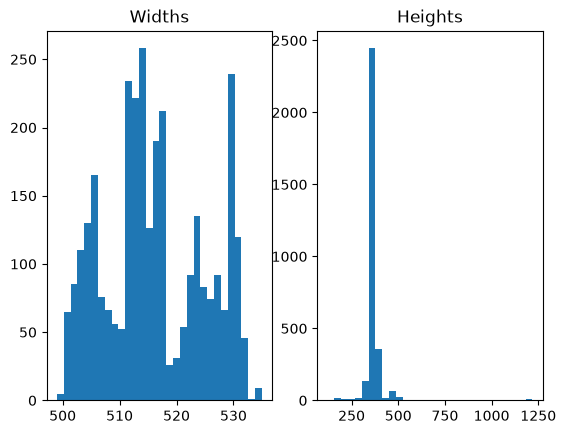

In [6]:
fig, axs = plt.subplots(1, 2)

axs[0].hist(widths, bins=30, label="widths")
axs[0].set_title("Widths")
axs[1].hist(heights, bins=30, label="heights")
axs[1].set_title("Heights")
plt.show()

In [7]:
size_counts = Counter((img["width"], img["height"]) for img in images_dict.values())
print(size_counts)

Counter({(514, 342): 195, (530, 341): 169, (513, 342): 134, (531, 341): 115, (527, 341): 90, (523, 341): 84, (516, 342): 82, (515, 342): 76, (525, 341): 76, (512, 342): 72, (516, 341): 71, (529, 341): 68, (528, 341): 64, (517, 341): 63, (526, 341): 63, (504, 343): 59, (522, 341): 59, (518, 341): 58, (502, 343): 52, (507, 340): 52, (521, 341): 49, (503, 343): 47, (511, 342): 46, (517, 342): 44, (524, 341): 39, (509, 344): 37, (514, 397): 37, (508, 343): 36, (505, 344): 33, (532, 341): 33, (506, 395): 32, (512, 341): 32, (501, 343): 27, (513, 341): 25, (513, 397): 25, (515, 341): 23, (513, 340): 23, (511, 341): 20, (519, 341): 19, (506, 399): 18, (503, 399): 17, (514, 341): 17, (506, 344): 16, (520, 341): 15, (510, 342): 15, (505, 399): 14, (512, 343): 13, (516, 510): 11, (508, 344): 11, (532, 396): 10, (501, 398): 10, (504, 375): 10, (502, 398): 9, (522, 477): 8, (503, 398): 8, (512, 340): 8, (506, 340): 8, (509, 342): 8, (511, 397): 8, (522, 476): 8, (504, 341): 7, (512, 397): 7, (510,

**Findings**
- Widths are clustered between ~500–535px, no outliers
- Heights are mainly ~340–345px, but the histogram tail and the counter reveal some outliers

### 2. Test set size check

In [8]:
test_images = []
for i in os.listdir(TEST_SET_PATH):
      img_path = os.path.join(TEST_SET_PATH, i)
      test_images.append(img_path)

In [9]:
test_widths = [Image.open(i).size[0] for i in test_images]
test_heights = [Image.open(i).size[1] for i in test_images]

test_size_counts = Counter(zip(test_widths, test_heights))
print(test_size_counts)

Counter({(514, 342): 58, (513, 342): 44, (530, 341): 39, (527, 341): 24, (531, 341): 22, (526, 341): 20, (523, 341): 19, (504, 343): 19, (516, 342): 18, (514, 397): 18, (525, 341): 16, (516, 341): 16, (528, 341): 15, (509, 344): 15, (517, 341): 15, (517, 342): 14, (507, 340): 13, (512, 342): 13, (515, 342): 12, (521, 341): 12, (529, 341): 12, (518, 341): 12, (532, 341): 11, (524, 341): 11, (506, 395): 11, (505, 344): 10, (515, 341): 10, (502, 343): 10, (503, 343): 10, (508, 343): 9, (513, 397): 9, (522, 341): 9, (520, 341): 8, (519, 341): 8, (510, 342): 8, (512, 341): 8, (511, 341): 6, (503, 399): 6, (513, 341): 6, (501, 343): 6, (511, 342): 6, (504, 344): 5, (504, 375): 5, (506, 344): 5, (514, 341): 4, (513, 340): 4, (504, 365): 3, (501, 398): 3, (503, 415): 3, (504, 341): 3, (506, 399): 3, (517, 345): 3, (509, 342): 3, (506, 340): 3, (512, 397): 3, (511, 397): 3, (512, 343): 3, (523, 494): 2, (511, 340): 2, (503, 398): 2, (504, 342): 2, (504, 396): 2, (510, 341): 2, (516, 476): 2, (5

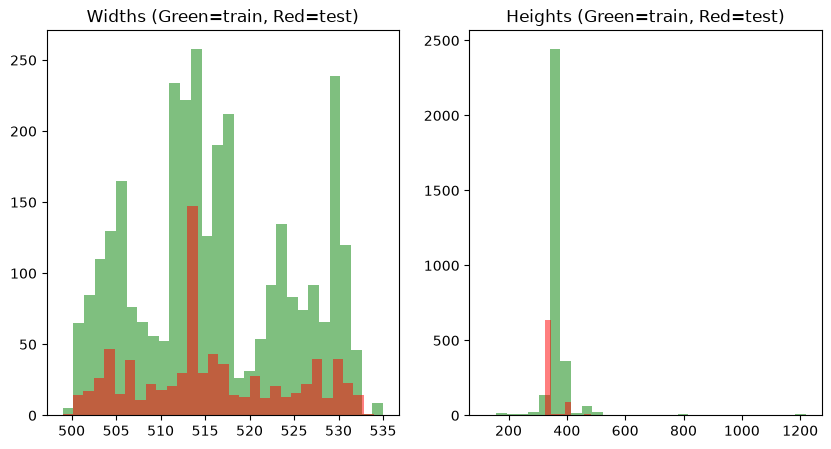

In [10]:
fig, axs = plt.subplots(1, 2)
fig.set_figheight(5)
fig.set_figwidth(10)

axs[0].hist(widths, bins=30, label="widths", color='green', alpha=0.5)
axs[0].hist(test_widths, bins=30, label="widths", color='red', alpha=0.5)
axs[0].set_title("Widths (Green=train, Red=test)")
axs[1].hist(heights, bins=30, label="heights", color='green', alpha=0.5)
axs[1].hist(test_heights, bins=30, label="heights", color="red", alpha=0.5)
axs[1].set_title("Heights (Green=train, Red=test)")
plt.show()

**Findings**
- Widths of the test set have the same 500–535px range, and same distribution shape
- Heights are mostly 340–345px
- Test set also has a few "tall" images 

### 3. Visual inspection

In [11]:
def show_examples(image_ids, cols=3):
      rows = math.ceil(len(image_ids) / cols)
      fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
      axes = axes.flatten()
      
      for i, img_id in enumerate(image_ids):
            img_info = images_dict[img_id]
            img_path = os.path.join(TRAIN_SET_PATH, img_info["file_name"])
            img = np.array(Image.open(img_path))
            
            axes[i].imshow(img)
            for ann in anns_by_image[img_id]:
                  x, y, w, h = ann["bbox"]
                  rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor="red", 
                                          fill=False)
                  axes[i].add_patch(rect)
            axes[i].set_title(f"id={img_id}, n={len(anns_by_image[img_id])}")
            axes[i].axis("off")
      
      for j in range(i + 1, len(axes)):
            axes[j].axis("off")
      
      plt.tight_layout()
      plt.show()

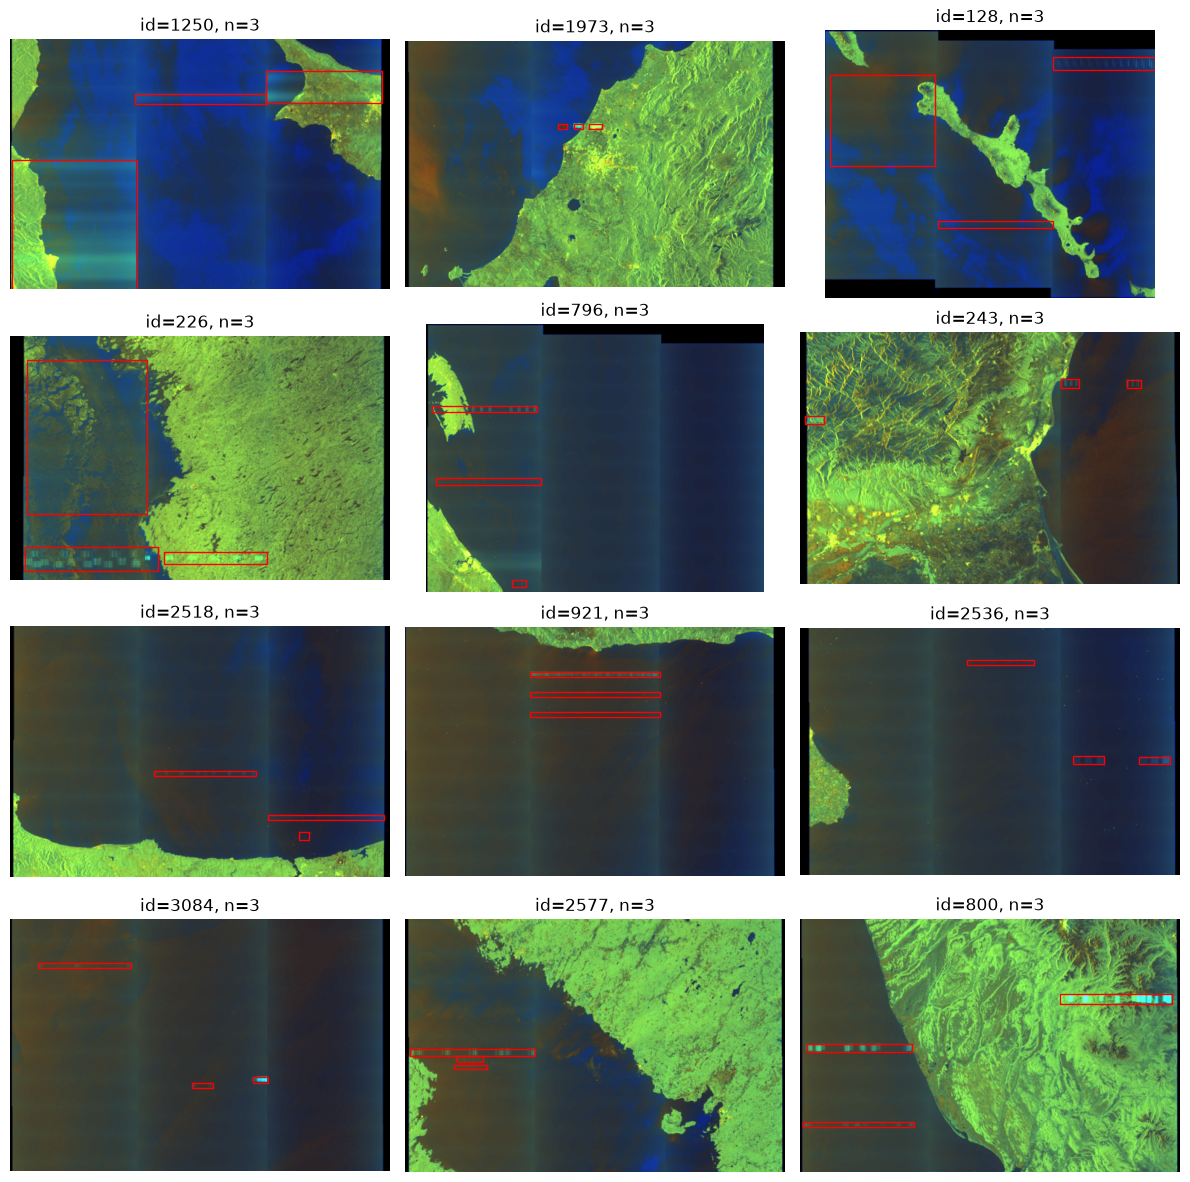

In [12]:
# extract "typical" IDs, i.e. where annotation counts is close to 3 (the median)
typical_ids = [img_id for img_id in anns_by_image if len(anns_by_image[img_id]) == 3]

show_examples(random.sample(typical_ids, 12))

**Findings**
- There are some thin horizontal boxes, with RFI patterns that are easy to spot
- There are some large boxes as well, probably a different type of interference that affects a whole region, although visually there is not anything odd that can be visualized.

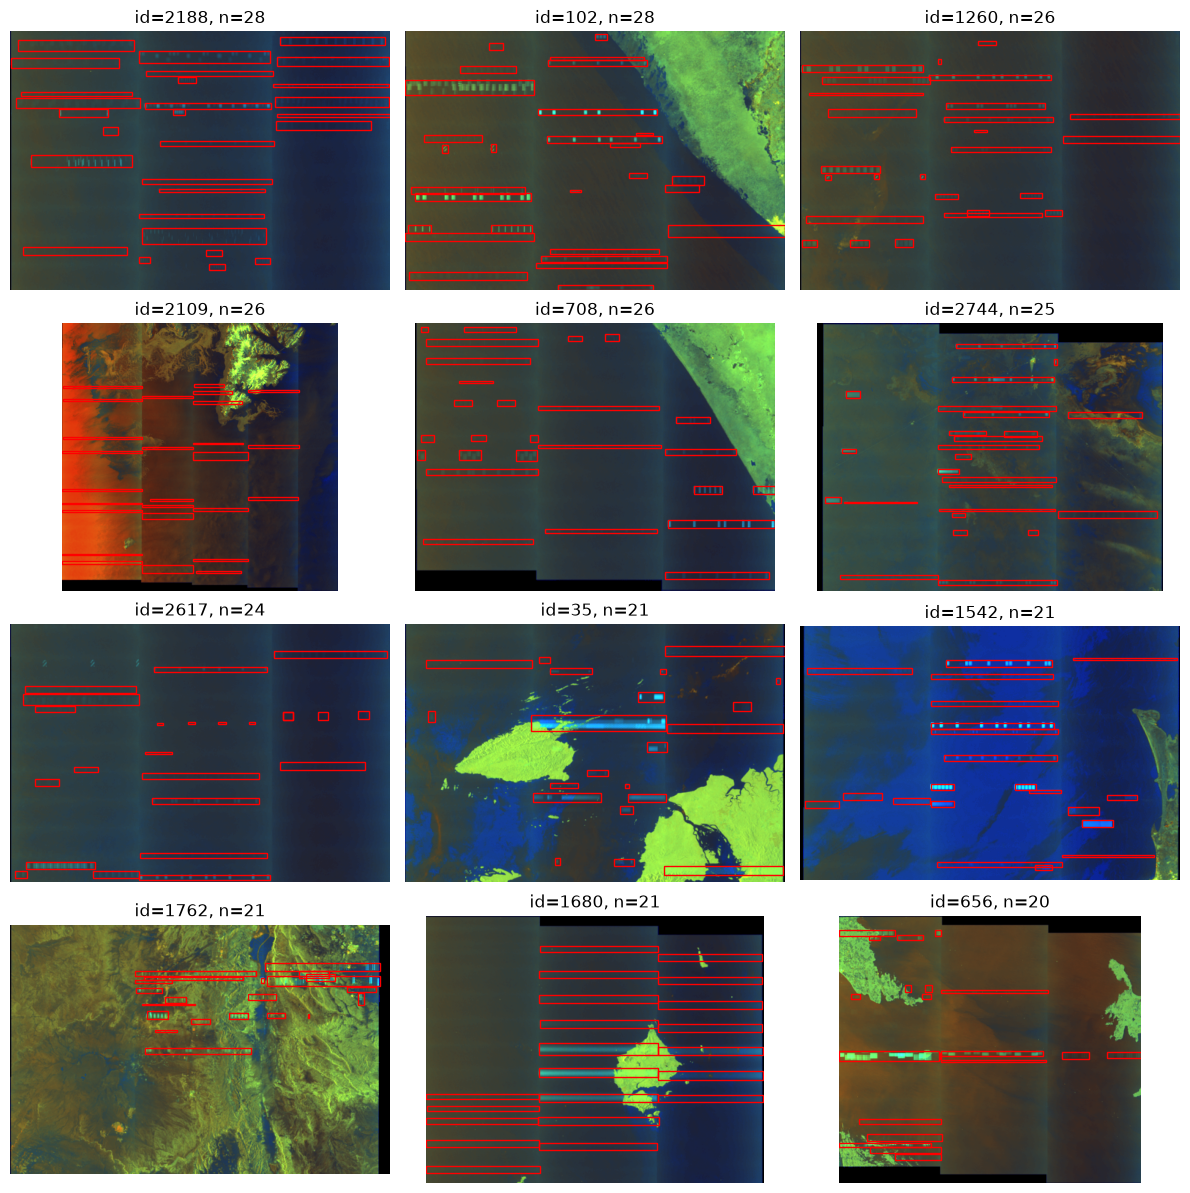

In [13]:
# let's also check some "dense" cases
dense_ids = sorted(anns_by_image, key=lambda x: len(anns_by_image[x]), reverse=True)[:12]

show_examples(dense_ids)

**Findings**:
- The "classic" thin horizontal detections are very clear here
- Many images show stacked parallel RFI streaks at the same X position but at different heights

In [14]:
# let's also investigate some edge cases

# group 1: tiny boxes
tiny_ids = list(set(ann["image_id"] for ann in annotations["annotations"] if ann["bbox"][3] == 1))

# group 2: big boxes
big_ids = list(set(ann["image_id"] for ann in annotations["annotations"] 
                  if ann["area"] / (images_dict[ann["image_id"]]["width"] * images_dict[ann["image_id"]]["height"]) >= 0.66))

# group 3: no RFIs (negative cases)
neg_ids = [img["id"] for img in annotations["images"] if img["id"] not in anns_by_image]

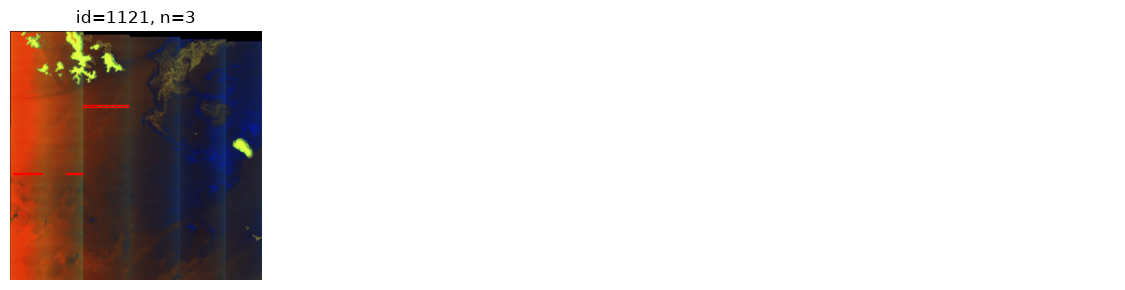

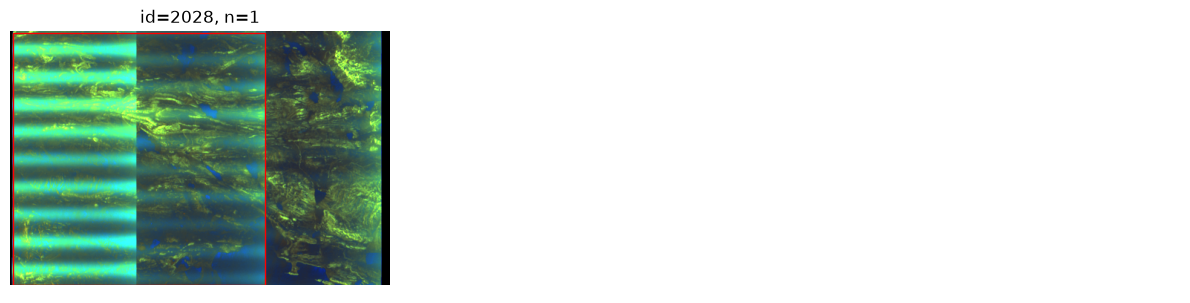

In [16]:
for i in [tiny_ids, big_ids]:
      show_examples(i)

**Findings**:
- The negative images show some suspicious examples, e.g. it seems annotators may have missed (or not annotated on purpose) some artifacts that really look like RFIs.

### 4. Investigate boxes (annotations) geometry

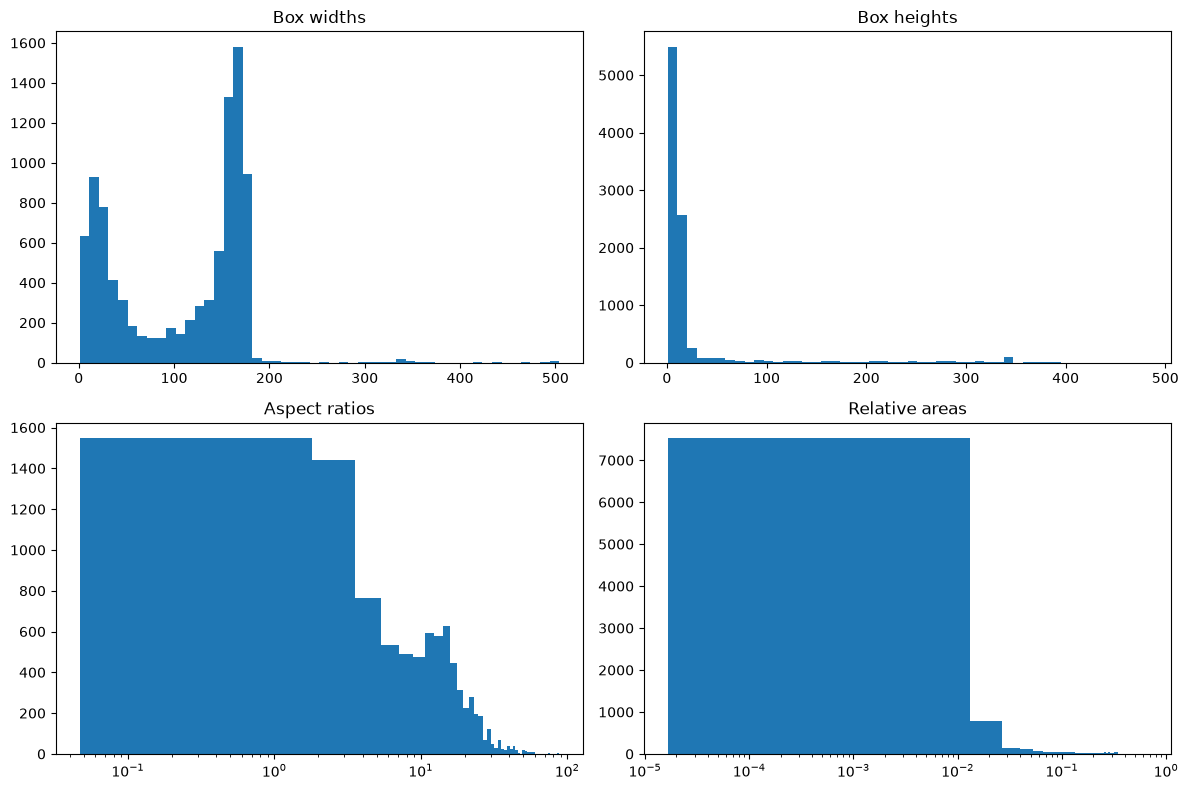

In [ ]:
ws, hs, aspect_ratios, relative_areas = [], [], [], []

for ann in annotations["annotations"]:
    w, h = ann["bbox"][2], ann["bbox"][3]
    img = images_dict[ann["image_id"]]
    img_w, img_h = img["width"], img["height"]
    
    ws.append(w)
    hs.append(h)
    aspect_ratios.append(w / h if h > 0 else 0)
    relative_areas.append((w * h) / (img_w * img_h))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(ws, bins=50)
axes[0, 0].set_title("Box widths")

axes[0, 1].hist(hs, bins=50)
axes[0, 1].set_title("Box heights")

# use log scale for both aspect ratios and relative areas, as widths are way bigger than lengths
axes[1, 0].hist(aspect_ratios, bins=50)
axes[1, 0].set_title("Aspect ratios")
axes[1, 0].set_xscale("log")

axes[1, 1].hist(relative_areas, bins=50)
axes[1, 1].set_title("Relative areas")
axes[1, 1].set_xscale("log")

plt.tight_layout()
plt.show()

Findings:
- box width is characterised by bimodal distribtuon. A cluster of small boxes (0-50 px) and then a dominant peak at around 150-180 px.
- box height distribution is extremely skewed, with a sharp sike at very small values. This confirms that RFIs are mainly thin streaks in the images
- aspect ratios are broadly spread, meaning that boxes range from nearly swuare to extremely elongated.
- relative areas show that the boxes cover less than 0.1% of an image, so they are predominantly small objects

### 5. Anchor analyis

In [ ]:
box_dims = np.array([[w, h] for w, h in zip(ws, hs)])

kmeans = KMeans(n_clusters=9, random_state=42, n_init=10)
kmeans.fit(box_dims)

anchors = sorted(kmeans.cluster_centers_, key=lambda x: x[0] * x[1])
print("Dataset-specific anchors (w, h):")
for a in anchors:
    print(f"  w={a[0]:.1f}, h={a[1]:.1f}, ratio={a[0]/a[1]:.1f}")

Dataset-specific anchors (w, h):
  w=18.5, h=8.4, ratio=2.2
  w=52.3, h=10.0, ratio=5.2
  w=110.4, h=10.2, ratio=10.9
  w=150.9, h=11.7, ratio=12.9
  w=172.3, h=13.5, ratio=12.8
  w=374.0, h=32.8, ratio=11.4
  w=161.1, h=103.4, ratio=1.6
  w=162.0, h=205.0, ratio=0.8
  w=163.4, h=320.8, ratio=0.5


Findings:
- Clusters 1-6 are the thin streaks very common in this dataset
- Cluster 7-9 are larger RFI cases, nearly swuared or even taller than wide, with heights up to 320 pixels

So we have two main RFI types in this dateset (as it was already discovered during the visual inspection step)

### 6. RFI count distribution (class imbalance check)

In [ ]:
all_ids = [img["id"] for img in annotations["images"]]
rfi_counts = [len(anns_by_image[img_id]) for img_id in all_ids]

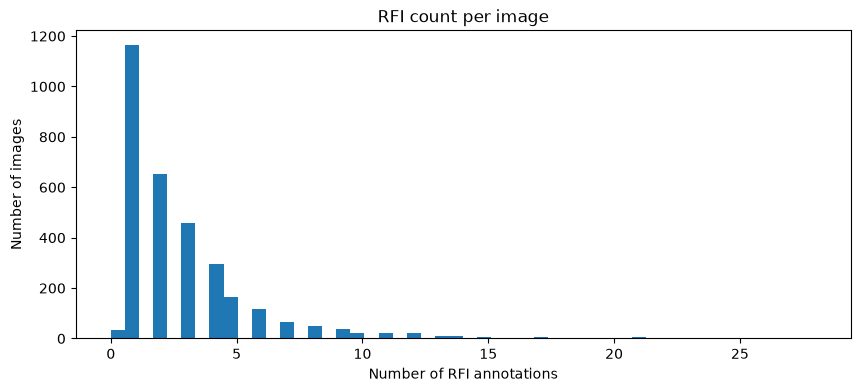

Mean: 2.94
Median: 2.00
Max: 28
<=1 RFI: 38.0%
<=3 RFI: 73.2%
<=10 RFI: 97.2%


In [ ]:
all_ids = [img["id"] for img in annotations["images"]]
rfi_counts = [len(anns_by_image[img_id]) for img_id in all_ids]

plt.figure(figsize=(10, 4))
plt.hist(rfi_counts, bins=50)
plt.title("RFI count per image")
plt.xlabel("Number of RFI annotations")
plt.ylabel("Number of images")
plt.show()

print(f"Mean: {np.mean(rfi_counts):.2f}")
print(f"Median: {np.median(rfi_counts):.2f}")
print(f"Max: {np.max(rfi_counts)}")
print(f"<=1 RFI: {sum(c <= 1 for c in rfi_counts) / len(rfi_counts) * 100:.1f}%")
print(f"<=3 RFI: {sum(c <= 3 for c in rfi_counts) / len(rfi_counts) * 100:.1f}%")
print(f"<=10 RFI: {sum(c <= 10 for c in rfi_counts) / len(rfi_counts) * 100:.1f}%")

Findings:
- Most images have 1-3 RFIs, with a long tail up to 25+
- 38% of the images have up to max 1 RFI, so a significant portion of the dataset is "easy" (very few objects to detect)
- 97.2% have up to 10 RFIs, so the dense cases (with many RFIs in the same images) are rare but exist
- 34 negatives represent a small minority

# Fixing the dataset